In [41]:
import csv
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import random
import requests
import numpy as np
import time
import math
from statistics import mean

In [42]:
# Given by tutoring staff, not participants
import os, gzip, shutil, urllib.request

def download_and_extract(url, out_path):
    """Download a .gz file and decompress it to out_path. Pure Python, works on any OS."""
    if os.path.exists(out_path):
        print(f"'{out_path}' is already here - skipping download.")
        return out_path

    gz_path = out_path + ".gz"
    print(f"Downloading {url}")
    # Some servers reject the default urllib agent, so we set a browser-like one.
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req) as resp, open(gz_path, "wb") as f:
        shutil.copyfileobj(resp, f)

    print("Decompressing...")
    with gzip.open(gz_path, "rb") as f_in, open(out_path, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    os.remove(gz_path)                      # drop the .gz, keep the plain file

    print("Ready:", os.path.abspath(out_path))
    return out_path

print("Working folder:", os.getcwd())

Working folder: /home/belugaboy/Schreibtisch/Biomed Data Science/Project/ChG-Interdecagon-Analysis-Summer-School-Team-Project-


In [43]:
# Given by tutoring staff, not participants
path = download_and_extract(
    "https://snap.stanford.edu/biodata/datasets/10016/files/ChG-InterDecagon_targets.csv.gz",
    "ChG-InterDecagon_targets.csv",
)


print("--- first 10 lines ---")
with open(path, "r") as f:
    for _ in range(10):
        print(f.readline().rstrip())

# Let Python's Sniffer guess the format from a small sample
with open(path, "r") as f:
    sample = f.read(2048)

dialect = csv.Sniffer().sniff(sample)
has_header = csv.Sniffer().has_header(sample)
print(f"\nDetected delimiter: {dialect.delimiter!r}")
print("Header row present:", has_header)


'ChG-InterDecagon_targets.csv' is already here - skipping download.
--- first 10 lines ---
# Drug	Gene
CID000060752,3757
CID006918155,2908
CID103052762,3359
CID023668479,1230
CID000028864,1269
CID000028864,124274
CID000028864,2849
CID000028864,2847
CID000028864,2844

Detected delimiter: 'D'
Header row present: False


In [44]:
# Use pandas to read the edge list (skip commented header) and build a bipartite graph
df = pd.read_csv(path, comment='#', header=None, names=['drug', 'gene'], dtype=str)

B = nx.Graph()
drugs = df['drug'].unique()
genes = df['gene'].unique()
B.add_nodes_from(drugs, bipartite=0, type='drug')
B.add_nodes_from(genes, bipartite=1, type='gene')
B.add_edges_from(df[['drug', 'gene']].itertuples(index=False, name=None))

print(f"Bipartite graph created: {B.number_of_nodes()} nodes, {B.number_of_edges()} edges")

Bipartite graph created: 9569 nodes, 131034 edges


In [45]:
def calculate_network_metrics(B, drug_list=None, gene_list=None):
    """
    Calculates and prints basic network metrics for a given bipartite graph B.
    Args:
        B (networkx.Graph): The bipartite graph for which to calculate metrics.
        drug_list (list): List of top (drug) nodes. If None, inferred from graph metadata.
        gene_list (list): List of bottom (gene) nodes. If None, inferred from graph metadata.
    """
    # Infer partitions from graph metadata if not provided
    if drug_list is None or gene_list is None:
        top_nodes, bottom_nodes = nx.bipartite.sets(B)
    else:
        top_nodes    = set(drug_list) & set(B.nodes())
        bottom_nodes = set(gene_list) & set(B.nodes())

    # Degrees per partition
    degree_map     = dict(nx.degree(B))
    top_degrees    = {n: degree_map[n] for n in top_nodes}
    bottom_degrees = {n: degree_map[n] for n in bottom_nodes}

    avg_degree        = mean(degree_map.values())     if degree_map     else 0.0
    avg_top_degree    = mean(top_degrees.values())    if top_degrees    else 0.0
    avg_bottom_degree = mean(bottom_degrees.values()) if bottom_degrees else 0.0

    density        = nx.bipartite.density(B, top_nodes)
    avg_clustering = nx.bipartite.average_clustering(B, mode="min")  # no intermediate dict

    print("--- Network Metrics (Bipartite) ---")
    print(f"Partition sizes: drugs={len(top_nodes)}, genes={len(bottom_nodes)}")
    print("Average Degree (all nodes):", avg_degree)
    print("Average Degree (drugs)    :", avg_top_degree)
    print("Average Degree (genes)    :", avg_bottom_degree)
    print("Bipartite Density         :", density)
    print("Average Clustering        :", avg_clustering)
    print("-----------------------------------")

    return {
        "avg_degree":        avg_degree,
        "avg_top_degree":    avg_top_degree,
        "avg_bottom_degree": avg_bottom_degree,
        "density":           density,
        "avg_clustering":    avg_clustering,
    }

In [46]:
def analyze_components(B):
    """
    Analyzes connected components of an undirected bipartite graph B.
    Args:
        B (networkx.Graph): The bipartite graph to analyze.
    """
    components = list(nx.connected_components(B))

    num_components   = len(components)
    largest_comp     = max(components, key=len)
    largest_comp_size = len(largest_comp)

    print("--- Connected Components ---")
    print("Number of components      :", num_components)
    print("Largest component (nodes) :", largest_comp_size)
    print("---------------------------")

    return {
        "components":        components,
        "num_components":    num_components,
        "largest_comp_size": largest_comp_size,
        "largest_comp":      largest_comp,      # node set, useful for subgraph extraction
    }

In [47]:
def centrality_measures(G):
    """
    Calculates Betweenness, Closeness, and Eigenvector centrality
    for a NetworkX graph using approximated methods.
    """
    # k=300 samples takes about 2 mins
    print("Computing Betweenness Centrality (Approximated)...")
    betweenness = nx.betweenness_centrality(G, k=300)
    avg_betweenness = sum(betweenness.values()) / len(betweenness)
    print("Average Betweenness Centrality:", avg_betweenness)
    print("Computing Closeness Centrality...")
    closeness = nx.closeness_centrality(G)
    print(closeness)
    avg = sum(closeness.values()) / len(closeness)
    print("Average Closeness Centrality:", avg)
    print("Computing Eigenvector Centrality...")
    try:
        eigenvector = nx.eigenvector_centrality(G, max_iter=1000)
        print(eigenvector)
        avg = sum(eigenvector.values()) / len(eigenvector)
        print("Average Eigenvector Centrality:", avg)
    except nx.PowerIterationFailedConvergence:
        print("Warning: Eigenvector centrality failed to converge. Returning None.")
        eigenvector = {node: None for node in G.nodes()}

    return betweenness, closeness, eigenvector

In [48]:
def visualize_components(B, drug_list, gene_list, max_components=10):
    """
    Visualizes connected components of a bipartite graph, coloring drugs and genes differently.
    Args:
        B (networkx.Graph): The bipartite graph.
        drug_list (list): List of drug nodes.
        gene_list (list): List of gene nodes.
        max_components (int): Max number of components to plot (by descending size).
    """
    drug_set = set(drug_list)
    gene_set = set(gene_list)

    # Sort components by size descending
    components = sorted(nx.connected_components(B), key=len, reverse=True)
    components_to_plot = components[:max_components]

    n = len(components_to_plot)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = axes.flatten() if n > 1 else [axes]

    for i, comp in enumerate(components_to_plot):
        ax = axes[i]
        subgraph = B.subgraph(comp)

        top    = [n for n in comp if n in drug_set]
        bottom = [n for n in comp if n in gene_set]

        # Bipartite layout: drugs on left, genes on right
        pos = nx.bipartite_layout(subgraph, top, align="horizontal")

        node_colors = ["#e05c5c" if n in drug_set else "#5c9ee0" for n in subgraph.nodes()]

        nx.draw(
            subgraph, pos,
            ax=ax,
            node_color=node_colors,
            node_shape = "o",
            node_size=2500,
            edge_color="#cccccc",
            with_labels=len(comp) <= 30,   # labels only for small components
            font_size=7,
        )


    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Shared legend
    legend_elements = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#e05c5c", markersize=20, label="Drug"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#5c9ee0", markersize=20, label="Gene"),
    ]
    fig.legend(handles=legend_elements, loc="lower right", ncol=2, fontsize=24)
    fig.suptitle(
        f"Connected Components of Bipartite Graph  (showing {n} of {len(components)})",
        fontsize=33, fontweight="bold", y=1.01
    )


    plt.tight_layout()
    plt.show()

--- Network Metrics (Bipartite) ---
Partition sizes: drugs=1774, genes=7795
Average Degree (all nodes): 27.38718779391786
Average Degree (drugs)    : 73.86358511837655
Average Degree (genes)    : 16.810006414368186
Bipartite Density         : 0.009475764607873836
Average Clustering        : 0.6694130855151147
-----------------------------------
--- Connected Components ---
Number of components      : 8
Largest component (nodes) : 9538
---------------------------
Computing Betweenness Centrality (Approximated)...
Average Betweenness Centrality: 0.0002061820873583338
Computing Closeness Centrality...
{'CID000060752': 0.21178791219701926, 'CID006918155': 0.26919549284861694, 'CID103052762': 0.24275646566468015, 'CID023668479': 0.28453711392029724, 'CID000028864': 0.32699599047033845, 'CID100003350': 0.29920683764952977, 'CID000060936': 0.28147041835084863, 'CID000003488': 0.3030219131989165, 'CID100000303': 0.31599575969694543, 'CID100005472': 0.3222516166298251, 'CID100005470': 0.3162691

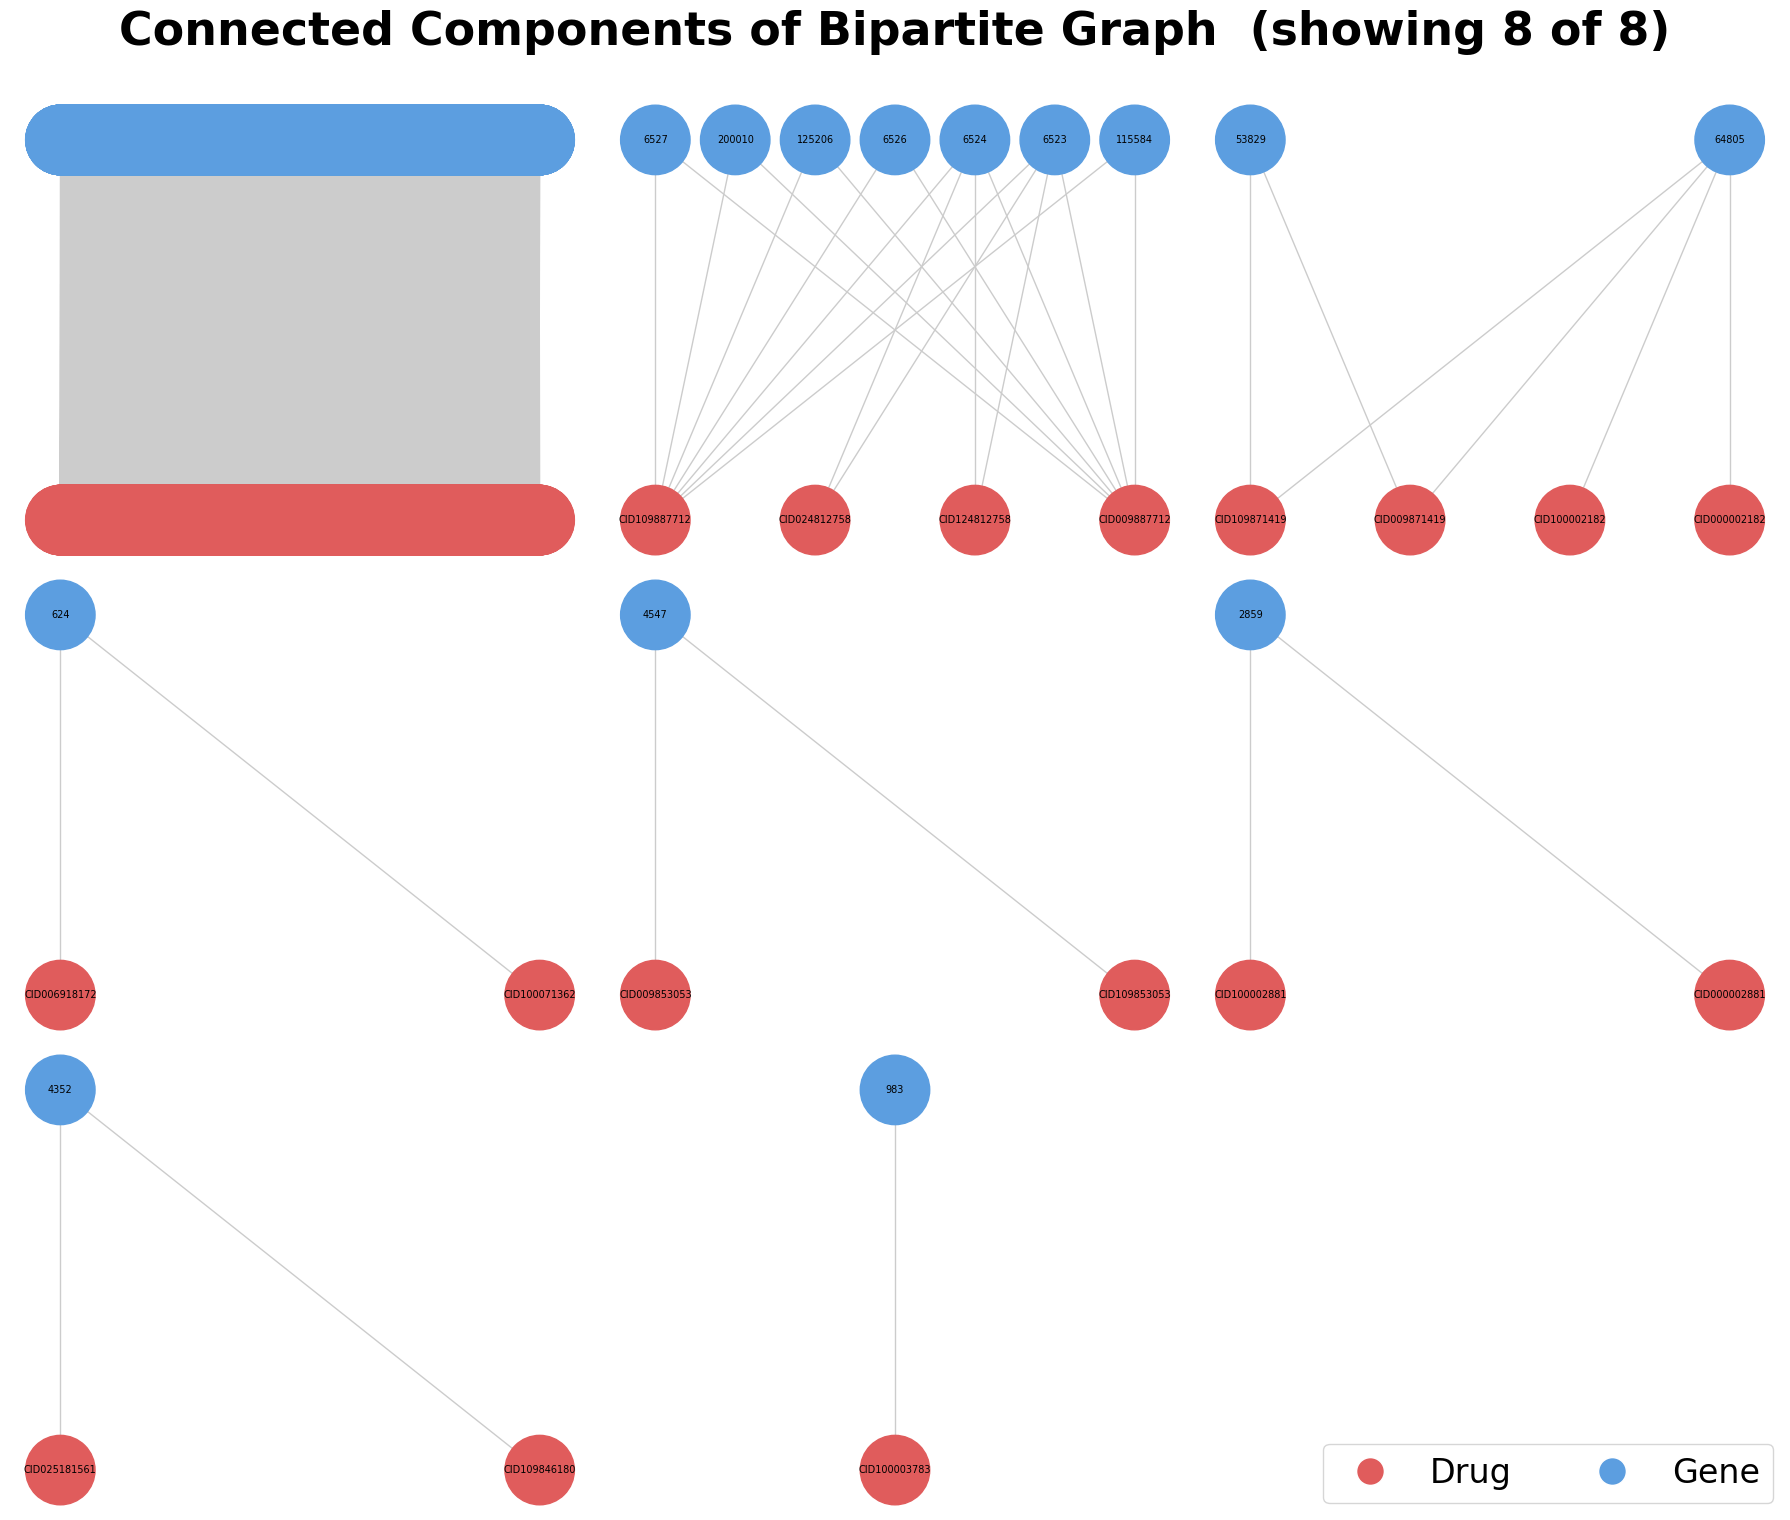

In [49]:
metrics = calculate_network_metrics(B, drugs, genes)
component_info = analyze_components(B)
b_cent, c_cent, e_cent = centrality_measures(B)
visualize_components(B, drugs, genes)